In [6]:
import functools
import matplotlib.pyplot as plt
import numpy as np
import torch
import seaborn as sns

from network import Net, NetDiscovery
from diff_equations import grad, cooling_law

sns.set_theme()
torch.manual_seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if torch.cuda.is_available():
    device = torch.device('cuda')
    torch.backends.cudnn.benchmark = True
else:
    device = torch.device('cpu')

if torch.cuda.is_available():
    torch.empty(1).to(DEVICE)

print(f"PyTorch will use: {DEVICE}")

PyTorch will use: cuda


# Parameters

In [ ]:
number_of_points = 1000
noise_coeff = 1

pinn_collocation_points = 5000
parameter_discovery_collocation_points = 10000

pinn_loss2_weight = 50
parameter_discovery_loss_2_weight = 100

physics_loss_discovery_randomize = True

pinn_epochs = 30000
parameter_discovery_epochs = 100000

Text(0.5, 0, 'Time (s)')

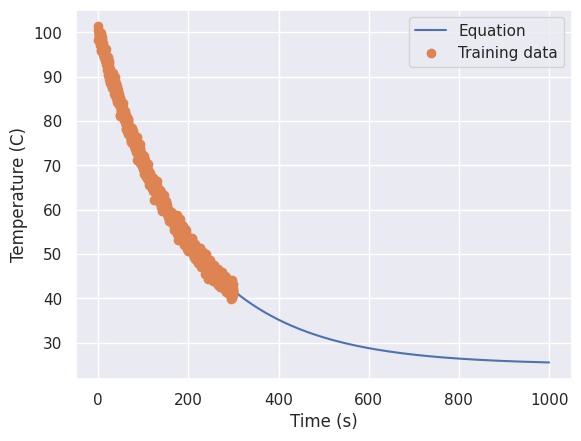

In [ ]:
np.random.seed(10)

Tenv = 25
T0 = 100
R = 0.005


times = np.linspace(0, 1000, number_of_points)
eq = functools.partial(cooling_law, Tenv=Tenv, T0=T0, R=R)
temps = eq(times)

# Make training data
t = np.linspace(0, 300, number_of_points)
T = eq(t) + noise_coeff * np.random.randn(number_of_points)

plt.plot(times, temps)
plt.plot(t, T, 'o')
plt.legend(['Equation', 'Training data'])
plt.ylabel('Temperature (C)')
plt.xlabel('Time (s)')

# PINN

In [ ]:
def physics_loss(model: torch.nn.Module, n_points=pinn_collocation_points):
    ts = torch.linspace(0, 1000, steps=n_points,).view(-1,1).requires_grad_(True).to(DEVICE)
    temps = model(ts)
    dT = grad(temps, ts)[0]
    pde = R*(Tenv - temps) - dT

    return torch.mean(pde**2)

/home/reza/temp/PINNs/.venv/lib/python3.11/site-packages/torch/autograd/graph.py:869: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:335.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch 0/30000, loss: 4519.7183
Epoch 3000/30000, loss: 2048.4602
Epoch 6000/30000, loss: 1621.6658
Epoch 9000/30000, loss: 82.2116
Epoch 12000/30000, loss: 34.0189
Epoch 15000/30000, loss: 18.0514
Epoch 18000/30000, loss: 3.9487
Epoch 21000/30000, loss: 1.0123
Epoch 24000/30000, loss: 0.9076
Epoch 27000/30000, loss: 0.8812


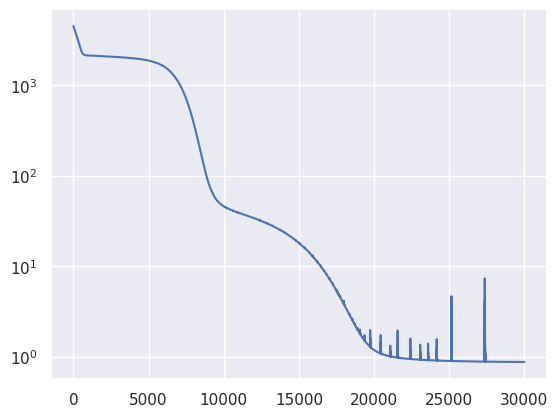

In [ ]:
net = Net(1,1, loss2=physics_loss, epochs=pinn_epochs, loss2_weight=pinn_loss2_weight, lr=1e-5).to(DEVICE)

losses = net.fit(t, T)
plt.plot(losses)
plt.yscale('log')

Text(0.5, 0, 'Time (s)')

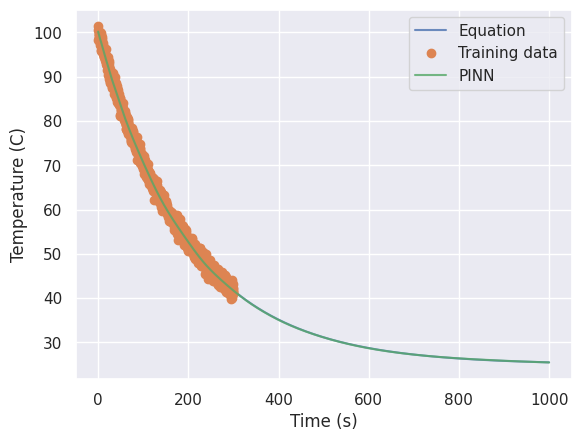

In [10]:
preds = net.predict(times)

plt.plot(times, temps, alpha=0.8)
plt.plot(t, T, 'o')
plt.plot(times, preds, alpha=0.8)
plt.legend(labels=['Equation','Training data', 'PINN'])
plt.ylabel('Temperature (C)')
plt.xlabel('Time (s)')

# Parameter discovery

In [ ]:
def physics_loss_discovery(model: torch.nn.Module, n_points=parameter_discovery_collocation_points, random=physics_loss_discovery_randomize):
    
    if random:
        ts = (torch.rand(n_points, 1, device=DEVICE) * 1000).requires_grad_(True) # random points
    else:
        ts = torch.linspace(0, 1000, steps=n_points,).view(-1,1).requires_grad_(True).to(DEVICE)

    temps = model(ts)
    dT = grad(temps, ts)[0]
    pde = torch.abs(model.r) * (Tenv - temps) - dT

    return torch.mean(pde**2)

Epoch 0/100000, loss: 4424.4961
Epoch 10000/100000, loss: 1659.2827
Epoch 20000/100000, loss: 56.9605
Epoch 30000/100000, loss: 2.9675
Epoch 40000/100000, loss: 0.8835
Epoch 50000/100000, loss: 0.8715
Epoch 60000/100000, loss: 0.8709
Epoch 70000/100000, loss: 0.8705
Epoch 80000/100000, loss: 0.8705
Epoch 90000/100000, loss: 0.8707


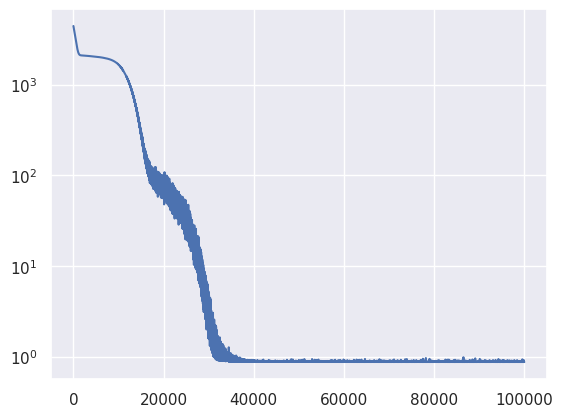

In [ ]:
netdisc = NetDiscovery(1, 1, loss2=physics_loss_discovery, loss2_weight=parameter_discovery_loss_2_weight, epochs=parameter_discovery_epochs, lr=5e-6).to(DEVICE)

losses = netdisc.fit(t, T)

plt.plot(losses)
plt.yscale('log')

Parameter containing:
tensor([0.0050], device='cuda:0', requires_grad=True)


Text(0.5, 0, 'Time (s)')

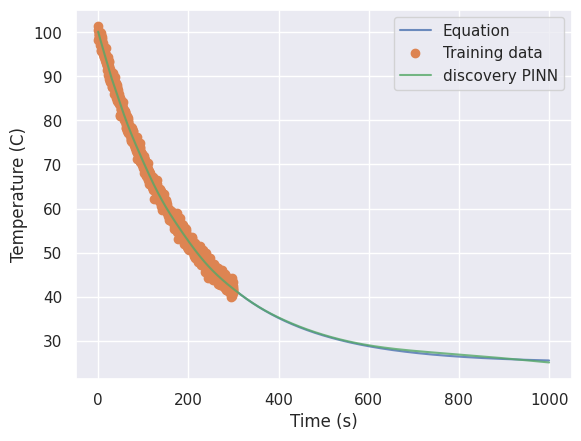

In [13]:
preds = netdisc.predict(times)
print(netdisc.r)

plt.plot(times, temps, alpha=0.8)
plt.plot(t, T, 'o')
plt.plot(times, preds, alpha=0.8)
plt.legend(labels=['Equation','Training data', 'discovery PINN'])
plt.ylabel('Temperature (C)')
plt.xlabel('Time (s)')